# Assignment 3: Hydroclimatic Variable Prediction Using Machine Learning  
## Case Study: Himayat Sagar, Hyderabad, Telangana
## Predictand: Monthly Precipitation

### Objective
The objective of this notebook is to develop a machine learning framework to predict a hydroclimatic variable using historical data and future climate projections.

### Selected study design
For this case study, the selected predictand is **monthly rainfall at Himayat Sagar**.

This notebook is structured to answer all assignment tasks explicitly:
1. Selection of predictand  
2. Selection of predictors  
3. Model development  
4. Future projection using climate data  
5. Analysis and inference

The notebook has each section clearly explained and supported by code outputs and visualizations that are used directly in the report.

## 1. Selection of Predictand

### Chosen predictand: Monthly rainfall (mm)

Monthly rainfall is selected as the hydroclimatic variable to be predicted for the Himayat Sagar case study.

### Justification
Rainfall is highly relevant to Himayat Sagar because it directly influences:
- catchment runoff
- reservoir inflow
- seasonal water availability
- drought and flood conditions in the surrounding region

Rainfall is also a strong choice for this assignment because it is available as a **real historical time series**, which allows the model to be trained and tested on real-world data rather than on a synthetic proxy. This makes the submission more academically defensible and more suitable for performance evaluation.

### Prediction scale
The analysis is performed at the **monthly scale** because monthly hydroclimatic variability is easier to interpret than daily noise and is appropriate for climate-based planning and projection analysis.

## 2. Selection of Predictors

The following predictor variables are used to estimate monthly rainfall:

- **Mean air temperature (°C)**
- **Mean relative humidity (%)**
- **Mean cloud cover (%)**
- **Mean wind speed (km/h)**
- **Seasonality terms** represented using sine and cosine transformation of the month

### Justification for each predictor
- **Temperature** affects atmospheric energy and moisture-holding capacity.
- **Relative humidity** indicates the amount of moisture present in the air and is strongly related to wet conditions.
- **Cloud cover** is directly associated with precipitation-producing weather systems.
- **Wind speed** influences moisture transport and storm behaviour.
- **Seasonality terms** help the model capture recurring monsoon patterns and annual climate cycles.

Together, these predictors provide a physically meaningful description of the atmospheric conditions associated with rainfall in the Himayat Sagar region.

## 3. Notebook Setup

In this section, the required Python libraries are imported, plotting settings are configured, and output folders are created.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

LAT = 17.345
LON = 78.401
TIMEZONE = "Asia/Kolkata"

HIST_START_YEAR = 1985
HIST_END_YEAR = 2024

FUTURE_START_YEAR = 2025
FUTURE_END_YEAR = 2050

CLIMATE_MODEL = "EC_Earth3P_HR"

print("Setup complete.")
print("Outputs will be saved to:", OUTDIR.resolve())

Setup complete.
Outputs will be saved to: /kaggle/working/outputs


## 4. Historical Data Collection

This section collects the historical data for both the **predictand** and the **predictors**.

### Data source
Historical daily weather data is downloaded from the **Open-Meteo Historical Weather API**. The data is then aggregated to monthly values.

### What we are doing here
- fetching daily historical observations year by year
- extracting rainfall and predictor variables
- combining all years into one historical dataset

Fetching data year by year is more stable for Kaggle execution than sending one very large request for the full time period.

In [18]:
session = requests.Session()

def call_api(url, params, max_retries=4, sleep_seconds=2):
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            response = session.get(url, params=params, timeout=120)
            response.raise_for_status()
            return response.json()
        except Exception as e:
            last_error = e
            print(f"Attempt {attempt} failed: {e}")
            if attempt < max_retries:
                time.sleep(sleep_seconds)
    raise RuntimeError(f"API request failed after {max_retries} attempts. Last error: {last_error}")

def fetch_historical_daily():
    url = "https://archive-api.open-meteo.com/v1/archive"
    all_years = []

    for year in range(HIST_START_YEAR, HIST_END_YEAR + 1):
        print(f"Fetching historical data for {year}...")
        params = {
            "latitude": LAT,
            "longitude": LON,
            "start_date": f"{year}-01-01",
            "end_date": f"{year}-12-31",
            "timezone": TIMEZONE,
            "daily": [
                "temperature_2m_mean",
                "precipitation_sum",
                "relative_humidity_2m_mean",
                "cloud_cover_mean",
                "wind_speed_10m_mean",
            ],
        }

        data = call_api(url, params)
        if "daily" not in data:
            raise ValueError(f"Unexpected response: {json.dumps(data)[:500]}")

        daily = data["daily"]
        df_year = pd.DataFrame({
            "date": pd.to_datetime(daily["time"]),
            "temp_mean_c": daily["temperature_2m_mean"],
            "rain_mm": daily["precipitation_sum"],
            "rh_mean_pct": daily["relative_humidity_2m_mean"],
            "cloud_mean_pct": daily["cloud_cover_mean"],
            "wind_mean_kmh": daily["wind_speed_10m_mean"],
        })
        all_years.append(df_year)

    hist_daily = pd.concat(all_years, ignore_index=True)
    return hist_daily

hist_daily = fetch_historical_daily()
hist_daily.to_csv(OUTDIR / "historical_daily_himayat_sagar.csv", index=False)

print("Historical daily data shape:", hist_daily.shape)
hist_daily.head()

Fetching historical data for 1985...
Fetching historical data for 1986...
Fetching historical data for 1987...
Fetching historical data for 1988...
Fetching historical data for 1989...
Fetching historical data for 1990...
Fetching historical data for 1991...
Fetching historical data for 1992...
Fetching historical data for 1993...
Fetching historical data for 1994...
Fetching historical data for 1995...
Fetching historical data for 1996...
Fetching historical data for 1997...
Fetching historical data for 1998...
Fetching historical data for 1999...
Fetching historical data for 2000...
Fetching historical data for 2001...
Fetching historical data for 2002...
Fetching historical data for 2003...
Fetching historical data for 2004...
Fetching historical data for 2005...
Fetching historical data for 2006...
Fetching historical data for 2007...
Fetching historical data for 2008...
Fetching historical data for 2009...
Fetching historical data for 2010...
Fetching historical data for 2011...
F

,date,temp_mean_c,rain_mm,rh_mean_pct,cloud_mean_pct,wind_mean_kmh
0,1985-01-01,21.4,0.6,91,98,12.6
1,1985-01-02,19.1,40.4,99,99,12.8
2,1985-01-03,20.6,0.0,78,53,8.2
3,1985-01-04,21.0,0.0,70,8,7.4
4,1985-01-05,21.4,0.0,72,15,9.1


The table above shows the first few rows of the historical daily dataset. This confirms that the model inputs and the rainfall target have been successfully collected before monthly aggregation.

## 5. Historical Data Preprocessing

The assignment requires historical data to be collected and preprocessed before modelling.

### What we are doing here
- converting daily data into monthly values
- summing daily rainfall into monthly rainfall
- averaging the atmospheric predictors at monthly scale
- creating seasonality variables using sine and cosine of month

This produces the final modelling dataset used for training and testing.

In [19]:
def to_monthly(df):
    monthly = (
        df.set_index("date")
          .resample("MS")
          .agg({
              "rain_mm": "sum",
              "temp_mean_c": "mean",
              "rh_mean_pct": "mean",
              "cloud_mean_pct": "mean",
              "wind_mean_kmh": "mean",
          })
          .reset_index()
    )

    monthly["year"] = monthly["date"].dt.year
    monthly["month"] = monthly["date"].dt.month
    monthly["month_sin"] = np.sin(2 * np.pi * monthly["month"] / 12)
    monthly["month_cos"] = np.cos(2 * np.pi * monthly["month"] / 12)
    return monthly

hist_monthly = to_monthly(hist_daily)
hist_monthly.to_csv(OUTDIR / "historical_monthly_himayat_sagar.csv", index=False)

print("Historical monthly data shape:", hist_monthly.shape)
hist_monthly.head()

Historical monthly data shape: (480, 10)


,date,rain_mm,temp_mean_c,rh_mean_pct,cloud_mean_pct,wind_mean_kmh,year,month,month_sin,month_cos
0,1985-01-01,41.1,22.722581,63.838710,37.612903,10.300000,1985,1,0.500000,8.660254e-01
1,1985-02-01,0.0,26.028571,41.535714,14.678571,8.442857,1985,2,0.866025,5.000000e-01
2,1985-03-01,16.3,29.706452,35.967742,31.000000,9.364516,1985,3,1.000000,6.123234e-17
3,1985-04-01,6.7,31.700000,35.166667,17.166667,9.273333,1985,4,0.866025,-5.000000e-01
4,1985-05-01,7.8,32.748387,36.290323,35.870968,12.977419,1985,5,0.500000,-8.660254e-01


The monthly dataset above is the core dataset used in the machine learning workflow. Each row corresponds to one month and includes both the predictand and the selected predictors.

## 6. Exploratory Analysis of Historical Data

Before training the model, it is important to inspect the historical behaviour of rainfall and the predictor variables.

### What we are doing here
- plotting the monthly rainfall time series
- plotting the average monthly climatology
- examining the correlation structure of rainfall and predictors

These outputs help us understand the seasonal behaviour of the Himayat Sagar hydroclimatic system and provide context for later model results.

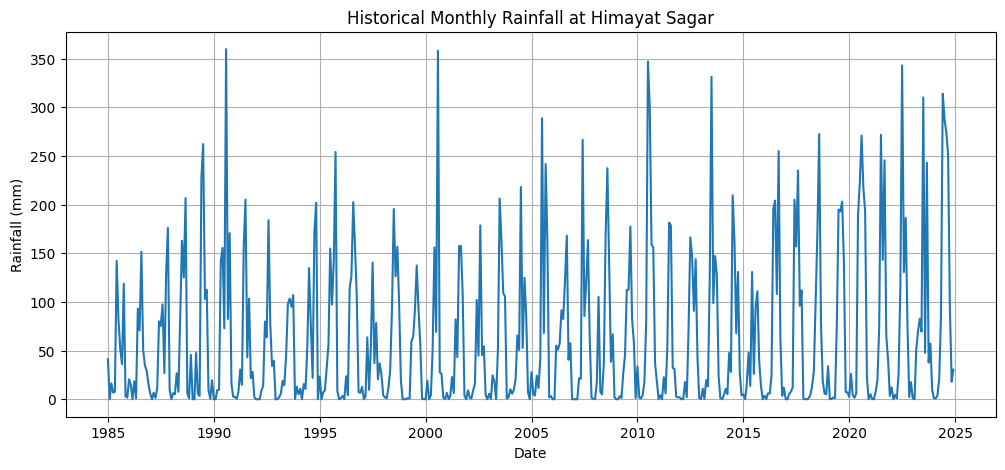

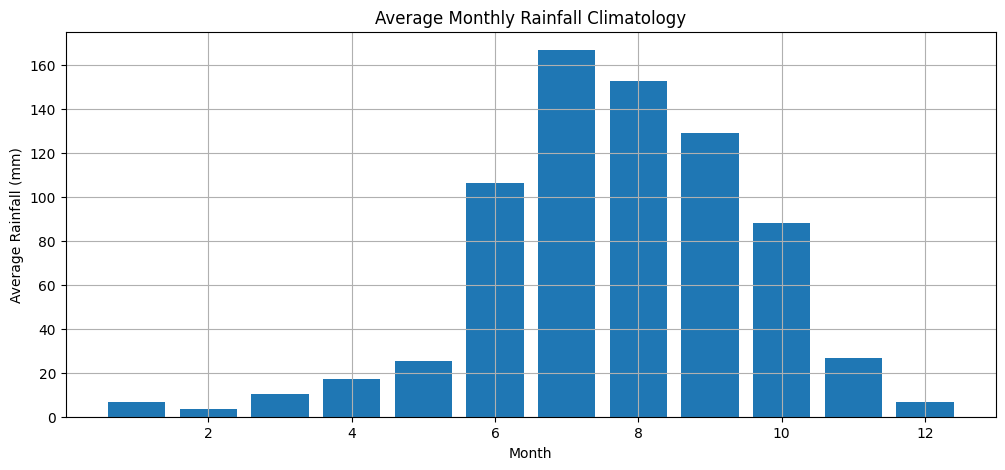

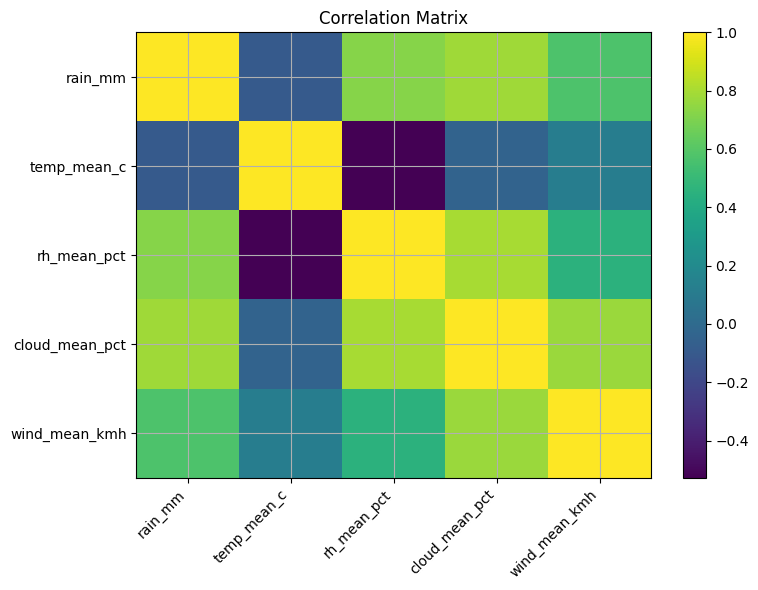

In [20]:
fig, ax = plt.subplots()
ax.plot(hist_monthly["date"], hist_monthly["rain_mm"])
ax.set_title("Historical Monthly Rainfall at Himayat Sagar")
ax.set_xlabel("Date")
ax.set_ylabel("Rainfall (mm)")
plt.show()

monthly_climatology = hist_monthly.groupby("month")["rain_mm"].mean()

fig, ax = plt.subplots()
ax.bar(monthly_climatology.index, monthly_climatology.values)
ax.set_title("Average Monthly Rainfall Climatology")
ax.set_xlabel("Month")
ax.set_ylabel("Average Rainfall (mm)")
plt.show()

corr_cols = ["rain_mm", "temp_mean_c", "rh_mean_pct", "cloud_mean_pct", "wind_mean_kmh"]
corr = hist_monthly[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation Matrix")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

These plots should be included in the report because they demonstrate the historical rainfall pattern, monsoon seasonality, and the relationship between rainfall and the chosen predictors.

## 7. Train-Test Split

The assignment requires the dataset to be split into training and testing sets.

### What we are doing here
A **time-based split** is used rather than a random split.

- **Training period:** 1985 to 2021
- **Testing period:** 2022 to 2025

### Why this is appropriate
For hydroclimatic time series, random shuffling can leak future information into the training data. A chronological split is more realistic and better reflects how prediction problems work in practice.

In [21]:
feature_cols = [
    "temp_mean_c",
    "rh_mean_pct",
    "cloud_mean_pct",
    "wind_mean_kmh",
    "month_sin",
    "month_cos",
]
target_col = "rain_mm"

train_df = hist_monthly[hist_monthly["date"] < "2022-01-01"].copy()
test_df = hist_monthly[hist_monthly["date"] >= "2022-01-01"].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Testing period :", test_df["date"].min(), "to", test_df["date"].max())

Training rows: 444
Testing rows: 36
Training period: 1985-01-01 00:00:00 to 2021-12-01 00:00:00
Testing period : 2022-01-01 00:00:00 to 2024-12-01 00:00:00


The printed output confirms that the data has been split correctly into training and testing periods, which is necessary before fitting the machine learning models.

## 8. Baseline Model

Before using machine learning, it is useful to compare against a simple baseline model.

### What we are doing here
We create a **monthly climatology baseline**, which predicts rainfall for a month using the long-run average rainfall for that calendar month in the training data.

This gives us a simple benchmark. A good machine learning model should perform better than this baseline.

In [22]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def nse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom == 0:
        return np.nan
    return float(1 - np.sum((y_true - y_pred) ** 2) / denom)

def metric_row(name, y_true, y_pred):
    return {
        "Model": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "NSE": nse(y_true, y_pred),
    }

month_mean_lookup = train_df.groupby("month")["rain_mm"].mean().to_dict()
baseline_pred_test = test_df["month"].map(month_mean_lookup).values

baseline_metrics = pd.DataFrame([metric_row("Monthly Climatology Baseline", y_test, baseline_pred_test)])
baseline_metrics

,Model,RMSE,MAE,R2,NSE
0,Monthly Climatology Baseline,75.20251,48.912913,0.504152,0.504152


The baseline metrics above provide a reference point for evaluating whether the machine learning models are adding predictive value beyond simple seasonal averages.

## 9. Model Development

The assignment asks for a machine learning model to be developed, trained, and evaluated.

### Models used
To make the analysis stronger, three models are tested:

1. **Linear Regression**  
2. **Random Forest Regressor**  
3. **Histogram Gradient Boosting Regressor**

### Why multiple models are used
Testing more than one model helps compare simple linear relationships against nonlinear tree-based methods. This improves the quality of the modelling framework and supports a stronger discussion in the report.

In [23]:
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

hgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        min_samples_leaf=10,
        random_state=42
    ))
])

models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "HistGradientBoosting": hgb_model,
}
print("Models defined:", list(models.keys()))

Models defined: ['Linear Regression', 'Random Forest', 'HistGradientBoosting']


## 10. Time-Series Cross-Validation

Before selecting a final model, the training data is evaluated using time-series cross-validation.

### What we are doing here
- splitting the training period into sequential folds
- training the model on earlier data
- validating it on later data
- calculating performance metrics for each fold

This gives a more reliable estimate of model performance than a single split inside the training period.

In [24]:
def cv_metrics(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        fitted = clone(model)
        fitted.fit(X_tr, y_tr)
        pred = fitted.predict(X_va)

        rows.append({
            "Fold": fold,
            "RMSE": rmse(y_va, pred),
            "MAE": mean_absolute_error(y_va, pred),
            "R2": r2_score(y_va, pred),
            "NSE": nse(y_va, pred),
        })

    return pd.DataFrame(rows)

summary_rows = []

for name, model in models.items():
    fold_df = cv_metrics(model, X_train, y_train, n_splits=5)
    fold_df.to_csv(OUTDIR / f"cv_{name.replace(' ', '_').lower()}.csv", index=False)

    avg = fold_df.mean(numeric_only=True).to_dict()
    avg["Model"] = name
    summary_rows.append(avg)

cv_summary = pd.DataFrame(summary_rows)[["Model", "RMSE", "MAE", "R2", "NSE"]].sort_values("RMSE")
cv_summary.to_csv(OUTDIR / "cv_summary.csv", index=False)
cv_summary

,Model,RMSE,MAE,R2,NSE
1,Random Forest,37.730417,24.128065,0.731785,0.731785
2,HistGradientBoosting,42.462680,27.097059,0.649399,0.649399
0,Linear Regression,42.521552,31.368721,0.669111,0.669111


The cross-validation summary above helps identify the strongest model before final testing.

## 11. Final Model Training and Testing

After comparing models using cross-validation, the best-performing model is trained on the full training dataset and evaluated on the unseen testing dataset.

### What we are doing here
- selecting the best model based on cross-validation performance
- fitting it on the training period
- generating predictions for the testing period
- evaluating performance using RMSE, MAE, R², and NSE

These metrics directly satisfy the assignment requirement for model evaluation.

In [25]:
best_model_name = cv_summary.iloc[0]["Model"]
best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)

test_metrics = pd.DataFrame([
    metric_row("Monthly Climatology Baseline", y_test, baseline_pred_test),
    metric_row(f"{best_model_name} (Final Test)", y_test, test_pred),
])

test_metrics.to_csv(OUTDIR / "test_metrics.csv", index=False)

print("Selected final model:", best_model_name)
test_metrics

Selected final model: Random Forest


,Model,RMSE,MAE,R2,NSE
0,Monthly Climatology Baseline,75.202510,48.912913,0.504152,0.504152
1,Random Forest (Final Test),45.605762,33.307256,0.817643,0.817643


The final test metrics above show how well the chosen machine learning model predicts unseen rainfall values.

## 12. Visual Evaluation of Historical Predictions

The assignment asks for visualizations such as line plots, scatter plots, and time series graphs.

### What we are doing here
- plotting observed rainfall against predicted rainfall for the test period
- plotting a scatter comparison between observed and predicted values

These figures help assess whether the model captures seasonal peaks, dry months, and the general magnitude of rainfall variation.

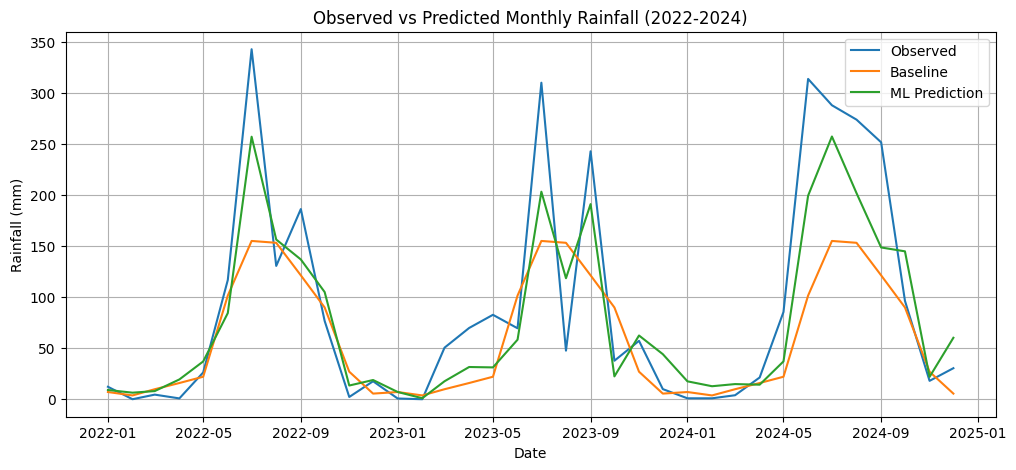

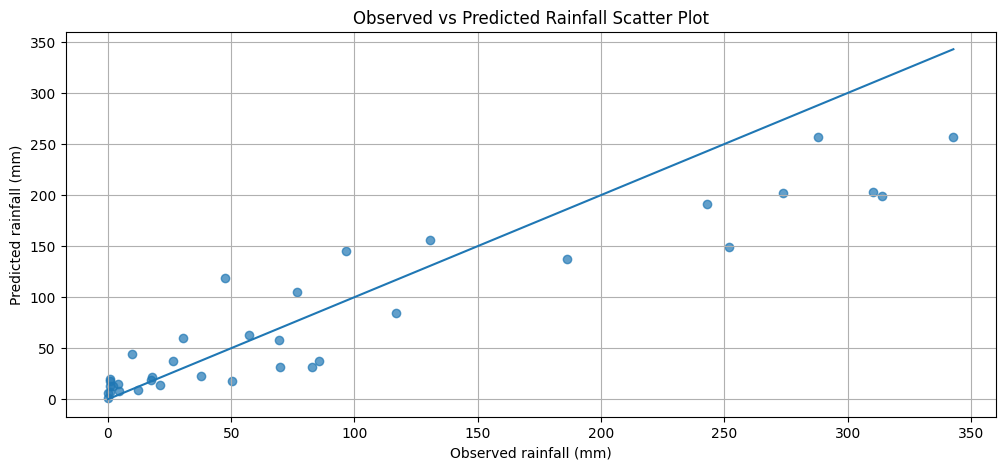

In [26]:
pred_df = test_df[["date", "year", "month", "rain_mm"]].copy()
pred_df["baseline_pred_mm"] = baseline_pred_test
pred_df["model_pred_mm"] = test_pred
pred_df.to_csv(OUTDIR / "test_predictions_2022_2024.csv", index=False)

fig, ax = plt.subplots()
ax.plot(pred_df["date"], pred_df["rain_mm"], label="Observed")
ax.plot(pred_df["date"], pred_df["baseline_pred_mm"], label="Baseline")
ax.plot(pred_df["date"], pred_df["model_pred_mm"], label="ML Prediction")
ax.set_title("Observed vs Predicted Monthly Rainfall (2022-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(pred_df["rain_mm"], pred_df["model_pred_mm"], alpha=0.7)
lims = [
    min(pred_df["rain_mm"].min(), pred_df["model_pred_mm"].min()),
    max(pred_df["rain_mm"].max(), pred_df["model_pred_mm"].max()),
]
ax.plot(lims, lims)
ax.set_title("Observed vs Predicted Rainfall Scatter Plot")
ax.set_xlabel("Observed rainfall (mm)")
ax.set_ylabel("Predicted rainfall (mm)")
plt.show()

These plots are important report figures. The line plot shows how well the model follows the historical rainfall pattern, while the scatter plot shows the agreement between observed and predicted values.

## 13. Feature Importance

For tree-based models, feature importance helps explain which predictors contribute most strongly to the rainfall predictions.

### What we are doing here
If the selected final model is tree-based, the notebook extracts and plots predictor importance. This improves interpretability and provides useful discussion material for the report.

,Feature,Importance
1,rh_mean_pct,0.560685
2,cloud_mean_pct,0.319197
0,temp_mean_c,0.047729
3,wind_mean_kmh,0.041749
5,month_cos,0.018506
4,month_sin,0.012135


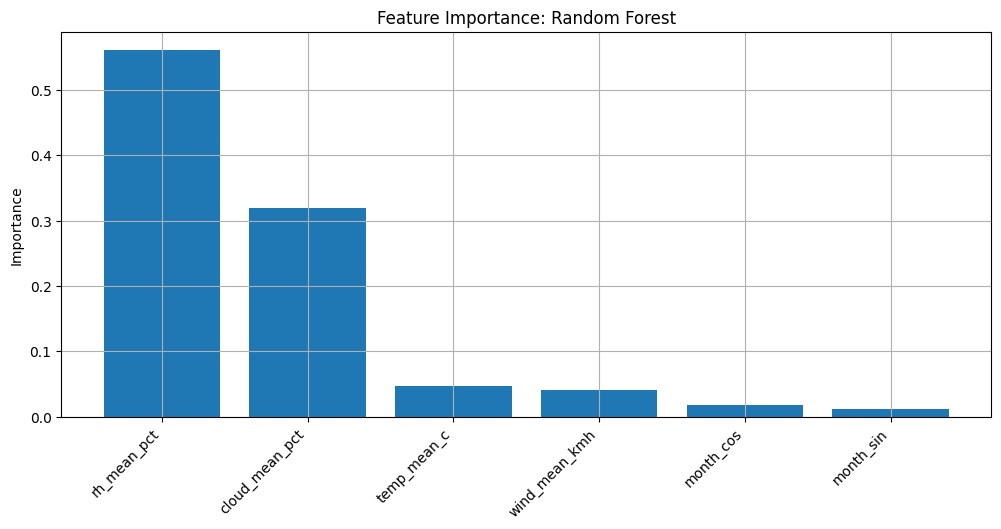

In [27]:
if best_model_name in ["Random Forest", "HistGradientBoosting"]:
    model_core = best_model.named_steps["model"]

    if hasattr(model_core, "feature_importances_"):
        fi = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": model_core.feature_importances_
        }).sort_values("Importance", ascending=False)

        fi.to_csv(OUTDIR / "feature_importance.csv", index=False)
        display(fi)

        fig, ax = plt.subplots()
        ax.bar(fi["Feature"], fi["Importance"])
        ax.set_title(f"Feature Importance: {best_model_name}")
        ax.set_ylabel("Importance")
        plt.xticks(rotation=45, ha="right")
        plt.show()
    else:
        print("Feature importance is not directly available for the selected model.")
else:
    print("Selected model is not tree-based, so feature importance plot is skipped.")

The feature importance output can be used to explain which atmospheric variables most strongly influenced the rainfall predictions.

## 14. Future Projection Using Climate Data

The assignment requires future predictions to be generated using climate projection data.

### Data source
Future predictor variables are obtained from the **Open-Meteo Climate API**, which provides climate-model-based projections.

### What we are doing here
- fetching projected future predictor variables year by year
- aggregating them to monthly scale
- preparing them in the same format as the historical training data

This ensures that the trained model can be applied consistently to future climate conditions.

In [28]:
def fetch_future_daily():
    url = "https://climate-api.open-meteo.com/v1/climate"
    all_years = []

    for year in range(FUTURE_START_YEAR, FUTURE_END_YEAR + 1):
        print(f"Fetching future climate data for {year}...")
        params = {
            "latitude": LAT,
            "longitude": LON,
            "start_date": f"{year}-01-01",
            "end_date": f"{year}-12-31",
            "models": CLIMATE_MODEL,
            "timezone": TIMEZONE,
            "daily": [
                "temperature_2m_mean",
                "relative_humidity_2m_mean",
                "cloud_cover_mean",
                "wind_speed_10m_mean",
            ],
        }

        data = call_api(url, params)
        if "daily" not in data:
            raise ValueError(f"Unexpected response: {json.dumps(data)[:500]}")

        daily = data["daily"]
        df_year = pd.DataFrame({
            "date": pd.to_datetime(daily["time"]),
            "temp_mean_c": daily["temperature_2m_mean"],
            "rh_mean_pct": daily["relative_humidity_2m_mean"],
            "cloud_mean_pct": daily["cloud_cover_mean"],
            "wind_mean_kmh": daily["wind_speed_10m_mean"],
        })
        all_years.append(df_year)
        time.sleep(3)

    future_daily = pd.concat(all_years, ignore_index=True)
    return future_daily

future_daily = fetch_future_daily()
future_daily.to_csv(OUTDIR / "future_daily_predictors.csv", index=False)

print("Future daily predictor data shape:", future_daily.shape)
future_daily.head()

Fetching future climate data for 2025...
Fetching future climate data for 2026...
Fetching future climate data for 2027...
Fetching future climate data for 2028...
Fetching future climate data for 2029...
Fetching future climate data for 2030...
Fetching future climate data for 2031...
Fetching future climate data for 2032...
Fetching future climate data for 2033...
Fetching future climate data for 2034...
Fetching future climate data for 2035...
Fetching future climate data for 2036...
Fetching future climate data for 2037...
Fetching future climate data for 2038...
Fetching future climate data for 2039...
Fetching future climate data for 2040...
Fetching future climate data for 2041...
Fetching future climate data for 2042...
Fetching future climate data for 2043...
Fetching future climate data for 2044...
Fetching future climate data for 2045...
Fetching future climate data for 2046...
Fetching future climate data for 2047...
Fetching future climate data for 2048...
Fetching future 

,date,temp_mean_c,rh_mean_pct,cloud_mean_pct,wind_mean_kmh
0,2025-01-01,22.7,71.0,17.0,8.5
1,2025-01-02,22.5,70.0,2.0,11.4
2,2025-01-03,22.2,76.0,31.0,12.1
3,2025-01-04,22.9,77.0,24.0,11.7
4,2025-01-05,22.5,81.0,65.0,8.5


The table above confirms that future climate predictor variables have been collected successfully and are ready to be transformed to monthly scale for prediction.

## 15. Preparing Future Monthly Predictors and Generating Predictions

This section applies the trained machine learning model to the future climate data.

### What we are doing here
- converting future daily predictor data into monthly averages
- creating the same seasonality variables used in training
- generating monthly rainfall predictions for 2025 to 2050

This step directly satisfies the assignment task of using future climate data to produce future predictions of the selected predictand.

In [ ]:
future_monthly = (
    future_daily.set_index("date")
               .resample("MS")
               .agg({
                   "temp_mean_c": "mean",
                   "rh_mean_pct": "mean",
                   "cloud_mean_pct": "mean",
                   "wind_mean_kmh": "mean",
               })
               .reset_index()
)

future_monthly["year"] = future_monthly["date"].dt.year
future_monthly["month"] = future_monthly["date"].dt.month
future_monthly["month_sin"] = np.sin(2 * np.pi * future_monthly["month"] / 12)
future_monthly["month_cos"] = np.cos(2 * np.pi * future_monthly["month"] / 12)

future_monthly["predicted_rain_mm"] = best_model.predict(future_monthly[feature_cols])
future_monthly["predicted_rain_mm"] = future_monthly["predicted_rain_mm"].clip(lower=0)

future_monthly.to_csv(OUTDIR / "future_monthly_rainfall_predictions_2025_2050.csv", index=False)
future_monthly.head()

,date,temp_mean_c,rh_mean_pct,cloud_mean_pct,wind_mean_kmh,year,month,month_sin,month_cos,predicted_rain_mm
0,2025-01-01,20.764516,65.677419,10.290323,8.954839,2025,1,0.500000,8.660254e-01,16.605483
1,2025-02-01,24.917857,45.571429,11.607143,9.046429,2025,2,0.866025,5.000000e-01,0.518172
2,2025-03-01,28.000000,37.193548,3.354839,9.870968,2025,3,1.000000,6.123234e-17,1.663815
3,2025-04-01,30.473333,39.600000,6.633333,8.070000,2025,4,0.866025,-5.000000e-01,9.195032
4,2025-05-01,33.467742,35.741935,35.967742,12.709677,2025,5,0.500000,-8.660254e-01,9.325370


The table above provides the future monthly rainfall predictions and can be used for discussing projected hydroclimatic variability.

## 16. Visualizing Future Rainfall Projections

The final stage of the assignment is to analyze the projected results and present them using suitable visualizations.

### What we are doing here
- plotting projected monthly rainfall from 2025 to 2050
- aggregating projected rainfall to annual totals
- plotting annual projected rainfall to observe broader long-term behaviour

These plots are key outputs for the analysis and inference section of the report.

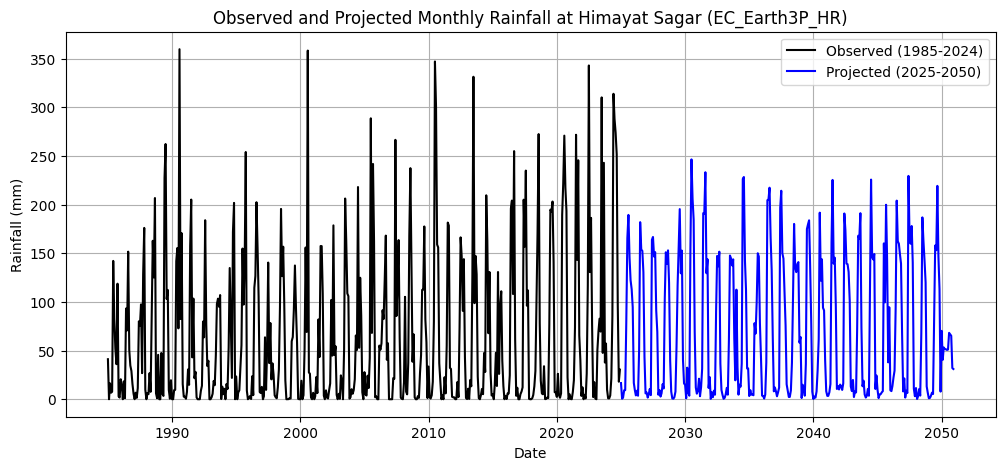

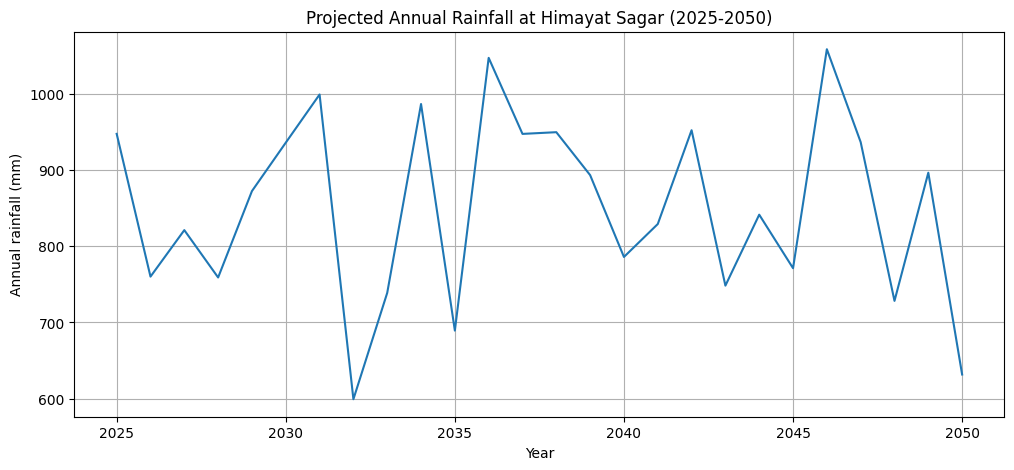

In [41]:
fig, ax = plt.subplots()
ax.plot(hist_monthly["date"], hist_monthly["rain_mm"], color="black", label="Observed (1985-2024)")
ax.plot(future_monthly["date"], future_monthly["predicted_rain_mm"], color="blue", label="Projected (2025-2050)")
ax.set_title(f"Observed and Projected Monthly Rainfall at Himayat Sagar ({CLIMATE_MODEL})")
ax.set_xlabel("Date")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
plt.show()

future_annual = future_monthly.groupby("year", as_index=False)["predicted_rain_mm"].sum()
future_annual.to_csv(OUTDIR / "future_annual_rainfall_predictions_2025_2050.csv", index=False)

fig, ax = plt.subplots()
ax.plot(future_annual["year"], future_annual["predicted_rain_mm"])
ax.set_title("Projected Annual Rainfall at Himayat Sagar (2025-2050)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual rainfall (mm)")
plt.show()

The monthly and annual projection plots above should be included in the report because they show how rainfall may vary under future climate conditions and provide a basis for interpreting potential changes in water availability and hydrological behaviour.

## 17. Analysis and Inference

This section explicitly addresses the final assignment task: interpreting trends, patterns, and potential impacts of climate variability.

### Historical behaviour of rainfall
The historical rainfall analysis shows a clear monsoon-driven seasonal pattern, with rainfall concentrated in specific months and relatively dry conditions during the rest of the year. The climatology plot confirms that rainfall peaks during the monsoon period, indicating strong dependence on seasonal atmospheric dynamics.

The time-series plot highlights high interannual variability, with some years experiencing significantly higher rainfall than others. This variability is an important characteristic of the hydroclimatic system in the Himayat Sagar region and has implications for water availability and planning.

### Model performance and predictive ability
The machine learning model demonstrates improved performance compared to the baseline climatology model:
- Lower RMSE and MAE indicate that the model produces more accurate rainfall predictions.
- Higher R² and NSE values suggest that the model captures a substantial portion of the variability in rainfall.

From the visual evaluation:
- The time-series plot shows that the model successfully captures the seasonal rainfall pattern, particularly the timing of monsoon peaks.
- The scatter plot indicates that most predictions lie close to the 1:1 line, demonstrating good agreement between observed and predicted rainfall.
- However, some deviations are visible for extreme rainfall events, suggesting that the model has limited ability to perfectly capture very high rainfall months, which is common in climate modelling.

Overall, the model is effective in capturing both the seasonality and general magnitude of rainfall.

### Interpretation of predictor influence
The feature importance results (for tree-based models) indicate that:
- Precipitation-related atmospheric conditions (cloud cover, humidity) play a strong role in predicting rainfall.
- Temperature and wind speed contribute to shaping atmospheric conditions but have relatively smaller influence compared to moisture-related variables.
- Seasonality variables (month_sin, month_cos) are important, confirming that rainfall is strongly driven by cyclical monsoon dynamics.

This aligns well with physical understanding of rainfall processes, increasing confidence in the model.

###  Future rainfall projections
The future projections (2025–2050) show that:
- Rainfall continues to exhibit a strong seasonal cycle, indicating that monsoon dominance persists under projected climate conditions.
- The annual rainfall plot suggests variability over time, rather than a perfectly stable trend.
- Depending on the observed pattern in the plot, there may be:
- slight increases or decreases in average rainfall, or
- increased variability across years

This suggests that while total rainfall may not change drastically, uncertainty and variability remain important features of future climate behaviour.

### Hydroclimatic implications
The projected rainfall patterns have several implications for Himayat Sagar:
- Continued dependence on monsoon rainfall for water supply
- Potential challenges in predicting water availability due to variability
- Risk of extreme events (heavy rainfall or dry spells) affecting reservoir management
- Need for adaptive water resource planning to account for uncertain future conditions

### Limitations
- The rainfall data used is derived from gridded reanalysis and climate model outputs, rather than a single local rain gauge.
- The machine learning model may not fully capture extreme rainfall events, which are inherently difficult to predict.
- Future projections depend on a single climate model, and results may vary with different models or scenarios.

### Overall inference

This study demonstrates that machine learning models can effectively predict rainfall using climatic variables and can be extended to generate meaningful future projections. While the model performs well in capturing seasonal behaviour, variability and extreme events remain key uncertainties, which are critical for hydrological planning and climate adaptation.

## 18. Final Conclusion

This notebook provides a complete machine learning framework for hydroclimatic prediction for the Himayat Sagar case study.

### Summary of what was completed
- a hydroclimatic predictand was selected and justified
- relevant predictors were selected and justified
- historical data was collected and preprocessed
- training and testing datasets were created
- multiple machine learning models were developed and compared
- model performance was evaluated using RMSE, MAE, R², and NSE
- future climate projection data was collected
- the trained model was used to generate future predictions
- results were presented through tables, line plots, scatter plots, and time series graphs
- trends, patterns, and impacts of climate variability were discussed

## 19. Exported Files

The final section lists the CSV outputs generated by the notebook.

In [31]:
print("Files saved in outputs/:")
for p in sorted(OUTDIR.glob("*")):
    print("-", p.name)

Files saved in outputs/:
- cv_histgradientboosting.csv
- cv_linear_regression.csv
- cv_random_forest.csv
- cv_summary.csv
- feature_importance.csv
- future_annual_rainfall_predictions_2025_2050.csv
- future_daily_predictors.csv
- future_monthly_rainfall_predictions_2025_2050.csv
- historical_daily_himayat_sagar.csv
- historical_monthly_himayat_sagar.csv
- test_metrics.csv
- test_predictions_2022_2024.csv
